In [3]:
import numpy as np
import matplotlib.pyplot as plt

def pearsonr(x, y):
    r = np.corrcoef(x, y)[0, 1]
    return r, None


def spearmanr(x, y):
    x_rank = np.argsort(np.argsort(x))
    y_rank = np.argsort(np.argsort(y))

    r = np.corrcoef(x_rank, y_rank)[0, 1]
    return r, None

print("NumPy:", np.__version__)

NumPy: 2.5.3


In [6]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)

NumPy: 2.5.3


In [7]:
np.random.seed(8)

city = "Poltava"

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

temperature = np.array([
    -5, -4, 1, 10, 16, 19,
    21, 20, 14, 8, 1, -3
])

heating_days = np.clip(
    18 - temperature + np.random.normal(0, 1.5, 12),
    0,
    30
)

heating_days = np.round(heating_days).astype(int)

heating_cost = (
    0.15 * heating_days
    + np.random.normal(0, 1.0, 12)
)

heating_cost = np.round(
    np.maximum(heating_cost, 0),
    1
)

print("Місто:", city)
print("Місяці:", months)
print("Температура:", temperature)
print("Опалювальні дні:", heating_days)
print("Витрати:", heating_cost)

Місто: Poltava
Місяці: ['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру']
Температура: [-5 -4  1 10 16 19 21 20 14  8  1 -3]
Опалювальні дні: [23 24 14  6  0  3  0  1  5 11 15 24]
Витрати: [2.3 2.9 1.7 0.1 0.9 0.2 0.  0.  2.1 1.  2.1 4. ]


In [8]:
print("\nКліматичні дані Полтави")
print("-" * 55)
print(f"{'Місяць':<10} {'Температура':<15} {'Дні':<10} {'Витрати':<10}")
print("-" * 55)

for i in range(12):
    print(
        f"{months[i]:<10} "
        f"{temperature[i]:<15} "
        f"{heating_days[i]:<10} "
        f"{heating_cost[i]:<10}"
    )


Кліматичні дані Полтави
-------------------------------------------------------
Місяць     Температура     Дні        Витрати   
-------------------------------------------------------
Січ        -5              23         2.3       
Лют        -4              24         2.9       
Бер        1               14         1.7       
Кві        10              6          0.1       
Тра        16              0          0.9       
Чер        19              3          0.2       
Лип        21              0          0.0       
Сер        20              1          0.0       
Вер        14              5          2.1       
Жов        8               11         1.0       
Лис        1               15         2.1       
Гру        -3              24         4.0       


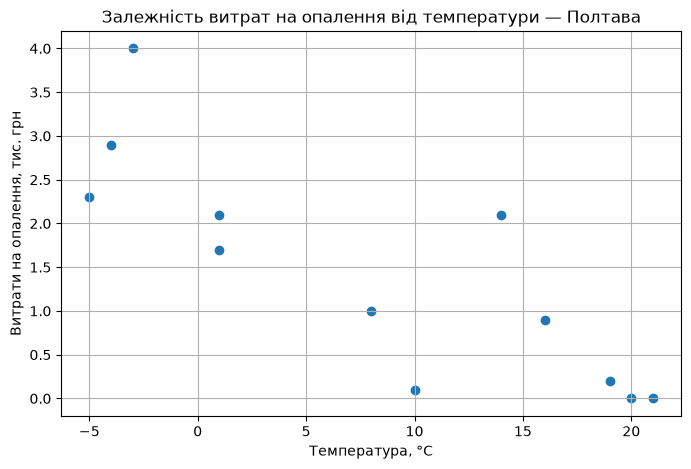

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(temperature, heating_cost)

plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Залежність витрат на опалення від температури — Полтава")

plt.grid(True)
plt.show()

In [10]:
def pearson_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    numerator = np.sum(x_centered * y_centered)

    denominator = np.sqrt(
        np.sum(x_centered ** 2) *
        np.sum(y_centered ** 2)
    )

    return numerator / denominator


r = pearson_correlation(
    temperature,
    heating_cost
)

print(f"Коефіцієнт Пірсона: r = {r:.3f}")


Коефіцієнт Пірсона: r = -0.828


In [11]:
def rank_data(values):
    values = np.asarray(values)

    order = np.argsort(values)

    ranks = np.empty(len(values), dtype=float)
    ranks[order] = np.arange(1, len(values) + 1)

    return ranks


def spearman_correlation(x, y):
    x_ranks = rank_data(x)
    y_ranks = rank_data(y)

    return pearson_correlation(
        x_ranks,
        y_ranks
    )


rho = spearman_correlation(
    temperature,
    heating_cost
)

print(f"Коефіцієнт Спірмена: rho = {rho:.3f}")


Коефіцієнт Спірмена: rho = -0.881


In [12]:
print("\nПорівняння коефіцієнтів:")
print(f"Пірсон:  {r:.3f}")
print(f"Спірмен: {rho:.3f}")
print(f"Різниця: {abs(r - rho):.3f}")


Порівняння коефіцієнтів:
Пірсон:  -0.828
Спірмен: -0.881
Різниця: 0.053


In [13]:
data = np.column_stack([
    temperature,
    heating_days,
    heating_cost
])

pearson_matrix = np.corrcoef(data, rowvar=False)

print("\nКореляційна матриця Пірсона:")

print(
    f"{'':20}"
    f"{'Температура':>15}"
    f"{'Опал. дні':>15}"
    f"{'Витрати':>15}"
)

names = [
    "Температура",
    "Опалювальні дні",
    "Витрати"
]

for i in range(3):
    print(
        f"{names[i]:<20}"
        f"{pearson_matrix[i,0]:>15.3f}"
        f"{pearson_matrix[i,1]:>15.3f}"
        f"{pearson_matrix[i,2]:>15.3f}"
    )


Кореляційна матриця Пірсона:
                        Температура      Опал. дні        Витрати
Температура                   1.000         -0.969         -0.828
Опалювальні дні              -0.969          1.000          0.861
Витрати                      -0.828          0.861          1.000


In [14]:
ranked_data = np.column_stack([
    rank_data(temperature),
    rank_data(heating_days),
    rank_data(heating_cost)
])

spearman_matrix = np.corrcoef(
    ranked_data,
    rowvar=False
)

print("\nКореляційна матриця Спірмена:")

print(
    f"{'':20}"
    f"{'Температура':>15}"
    f"{'Опал. дні':>15}"
    f"{'Витрати':>15}"
)

for i in range(3):
    print(
        f"{names[i]:<20}"
        f"{spearman_matrix[i,0]:>15.3f}"
        f"{spearman_matrix[i,1]:>15.3f}"
        f"{spearman_matrix[i,2]:>15.3f}"
    )


Кореляційна матриця Спірмена:
                        Температура      Опал. дні        Витрати
Температура                   1.000         -0.944         -0.881
Опалювальні дні              -0.944          1.000          0.895
Витрати                      -0.881          0.895          1.000


In [15]:
heating_cost_outlier = heating_cost.copy()

# Аварія на котельні в січні
heating_cost_outlier[0] *= 5

r_outlier = pearson_correlation(
    temperature,
    heating_cost_outlier
)

rho_outlier = spearman_correlation(
    temperature,
    heating_cost_outlier
)

print("\nПісля додавання аномального значення:")
print(f"Пірсон:  {r_outlier:.3f}")
print(f"Спірмен: {rho_outlier:.3f}")

print("\nПорівняння:")
print(f"Пірсон до викиду:    {r:.3f}")
print(f"Пірсон після викиду: {r_outlier:.3f}")
print()
print(f"Спірмен до викиду:    {rho:.3f}")
print(f"Спірмен після викиду: {rho_outlier:.3f}")


Після додавання аномального значення:
Пірсон:  -0.686
Спірмен: -0.902

Порівняння:
Пірсон до викиду:    -0.828
Пірсон після викиду: -0.686

Спірмен до викиду:    -0.881
Спірмен після викиду: -0.902


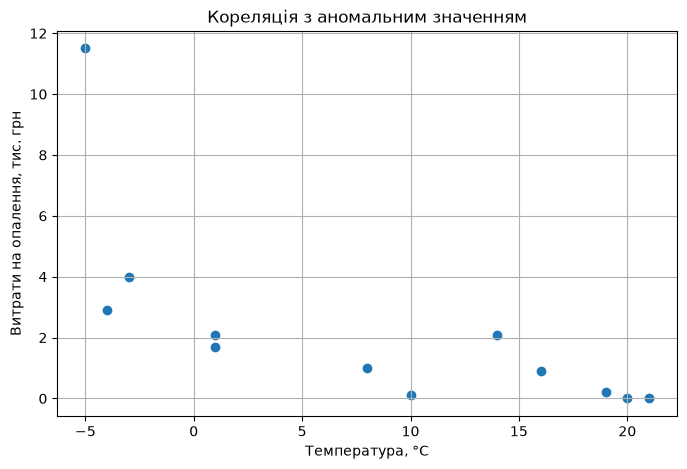

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    temperature,
    heating_cost_outlier
)

plt.xlabel("Температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Кореляція з аномальним значенням")

plt.grid(True)
plt.show()
